In [1]:
import numpy as np
import cv2
import PIL.Image as Image
import os
import matplotlib.pylab as plt
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import tf_keras as tfk

IMAGE_SHAPE = (224, 224)
model_url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"

classifier = tfk.Sequential([
    hub.KerasLayer(
        model_url, 
        input_shape=IMAGE_SHAPE + (3,),
        dtype=tf.float32
    )
])

classifier.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1001)              3540265   
                                                                 
Total params: 3540265 (13.51 MB)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 3540265 (13.51 MB)
_________________________________________________________________


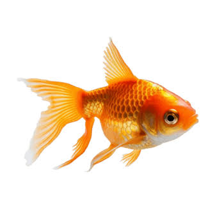

In [8]:
gold_fish = Image.open("gold_fish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [9]:
gold_fish = np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [10]:
gold_fish[np.newaxis, ...]

array([[[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        ...,

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]]], shape=(1, 224, 224, 3))

In [12]:
result=classifier.predict(gold_fish[np.newaxis,...])
result.shape

1/1 [==============================] - 1s 1s/step


(1, 1001)

In [13]:
predicted_label_index=np.argmax(result)
predicted_label_index

np.int64(2)

In [14]:
with open("ImageNetLabels.txt","r") as f:
  image_labels=f.read().splitlines()

image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

In [15]:
image_labels[predicted_label_index]

'goldfish'

In [18]:
#now we use this pretrained model on  flower dataset
import pathlib
data_dir = pathlib.Path('./flower_photos')

print("Dataset Path:", data_dir)
print("Total images:", len(list(data_dir.glob('*/*.jpg'))))

Dataset Path: flower_photos
Total images: 3670


In [19]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

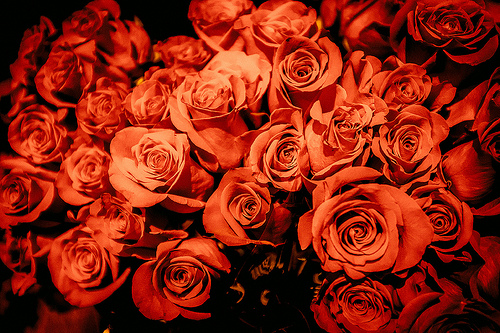

In [20]:
Image.open(str(roses[2]))

In [21]:
flower_images_dict={
  'roses':list(data_dir.glob('roses/*')),
  'daisy':list(data_dir.glob('daisy/*')),
  'dandelion':list(data_dir.glob('dandelion/*')),
  'sunflowers':list(data_dir.glob('sunflowers/*')),
  'tulips':list(data_dir.glob('tulips/*')),
}

In [22]:
flower_images_dict['roses']

[WindowsPath('flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('flower_photos/roses/110472418_87b6a3aa98_m.jpg'),
 WindowsPath('flower_photos/roses/11102341464_508d558dfc_n.jpg'),
 WindowsPath('flower_photos/roses/11233672494_d8bf0a3dbf_n.jpg'),
 WindowsPath('flower_photos/roses/11694025703_9a906fedc1_n.jpg'),
 WindowsPath('flower_photos/roses/118974357_0faa23cce9_n.jpg'),
 WindowsPath('flower_photos/roses/11944957684_2cc806276e.jpg'),
 WindowsPath('flower_photos/roses/12045735155_42547ce4e9_n.jpg'),
 WindowsPath('flower_photos/roses/12165480946_c4a3fe182d_n.jpg'),
 WindowsPath('flower_photos/roses/12202373204_34fb07205b.jpg'),
 WindowsPath('flower_photos/roses/12238827553_cf427bfd51_n.jpg'),
 WindowsPath('flower_photos/roses/12240165555_98625b1e88_n.jpg'),
 WindowsPath('flower_p

In [23]:
flower_labels_dict={
  'roses':0,
  'daisy':1,
  'dandelion':2,
  'sunflowers':3,
  'tulips':4
}

In [24]:
str(flower_images_dict['roses'][0])

'flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [27]:
img=cv2.imread(str(flower_images_dict['roses'][0]))
img.shape

(240, 179, 3)

In [31]:
x,y=[],[]
for flower_name,images in flower_images_dict.items():
  for image in images:
    img=cv2.imread(str(image))
    resized_img=cv2.resize(img,(224,224))
    x.append(resized_img)
    y.append(flower_labels_dict[flower_name])

In [33]:
x=np.array(x)
y=np.array(y)

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0)

In [35]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

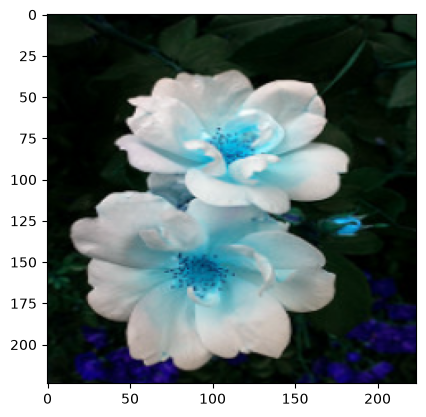

In [36]:
plt.axis=('off')
plt.imshow(x[0])

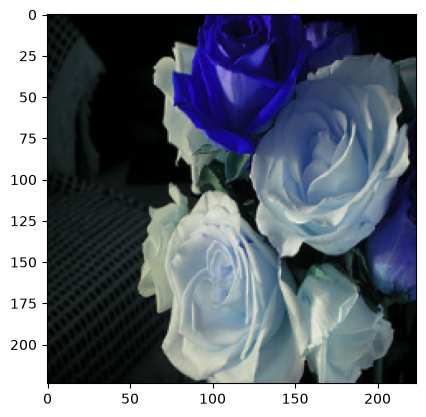

In [37]:
plt.axis=('off')
plt.imshow(x[1])

In [40]:
predicted=classifier.predict(np.array([x[0],x[1],x[2]]))
predicted=np.argmax(predicted,axis=1)
predicted

1/1 [==============================] - 0s 409ms/step


array([795, 880, 795])

In [43]:
image_labels[795]

'shower curtain'